In [5]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic

import cv2

from PIL import Image
from numpy.lib.stride_tricks import sliding_window_view

from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union


In [ ]:
%load_ext autoreload
%autoreload 2

import sys
for p in ['../../../../src']:
    if p not in sys.path:
        sys.path.append(p)
        
import spikeml as sml
from spikeml.utils.nb_util import xdisplay, Markup
from spikeml.ui.ipywidgets_ui import ui

from spikeml.core.runner import Context, DataRunner, run, nrun, Context, run_with, run_with_feedback


from spikeml.utils.vector import normalize, normalize_all

from spikeml.utils.img_util import show_img, show_imgs, cv_bgr2rgb
from spikeml.cv.img_stats import hist_cov
from spikeml.cv.img_stats import autocorr2d_fft, show_autocorr2d, autocorr_radial, show_autocorr_radial
from spikeml.cv.img_stats import img_cov, compute_show_img_cov, compute_show_img_kron, xshow_img

from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
SEED=37
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(edgeitems=3, infstr='inf', linewidth=120, nanstr='nan', precision=4, suppress=True, threshold=1000, formatter=None)


In [8]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data        # shape (70000, 784)
y = mnist.target     # labels as strings

(70000, 784) (70000,)
(70000, 28, 28) (70000,)


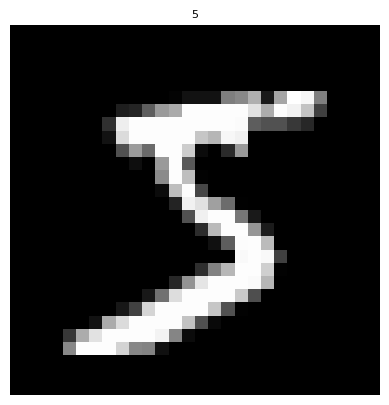

<Axes: title={'center': '5'}>

In [9]:
print(X.shape, y.shape)
y_ = y.astype(int) # Convert labels to int
X_ = X.reshape(-1, 28, 28)
print(X_.shape, y.shape)
show_img(X_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)



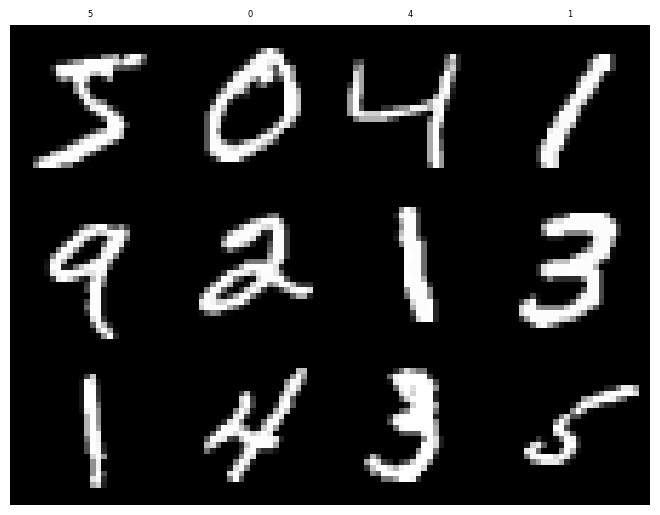

array([<Axes: title={'center': '5'}>, <Axes: title={'center': '0'}>, <Axes: title={'center': '4'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '9'}>, <Axes: title={'center': '2'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '3'}>, <Axes: title={'center': '1'}>,
       <Axes: title={'center': '4'}>, <Axes: title={'center': '3'}>, <Axes: title={'center': '5'}>], dtype=object)

In [10]:
show_imgs(X_[:12], titles=y[:12].tolist(), ncols=4, nrows=None, title_size=6, figsize=None, pad=0)


(70000, 28, 28)
(3, 3, 9, 9)
(3, 3, 9, 9) (9, 9, 9) (9, 81)


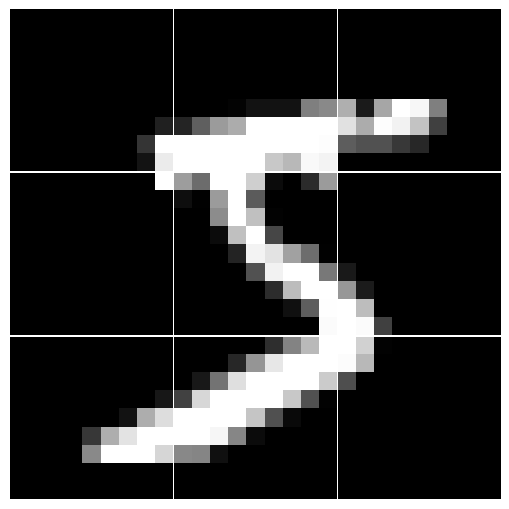

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [11]:

def tiles(a, K, S):
    tiles = sliding_window_view(a, (K, K))
    return tiles[::S, ::S]

print(X_.shape)

Xs=tiles(X_[0], K=9, S=9)
print(Xs.shape)

Xs_ = Xs.reshape(-1, *Xs.shape[2:])
Xs__ = Xs_.reshape(Xs_.shape[0], -1)
print(Xs.shape, Xs_.shape, Xs__.shape)
show_imgs(Xs_, titles=None, ncols=Xs.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)


(784,) int64
(784, 784)


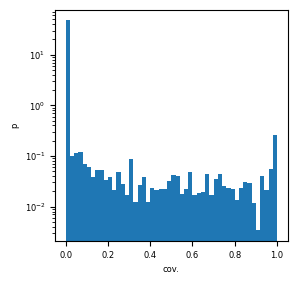

In [12]:
Xf = X.astype(float)/255
print(X[0].shape, X.dtype)
C = np.outer(Xf[0], Xf[0])
print(C.shape)
#for T in np.linspace(0, .1, num=22):
#    print(T, C.shape[0]*C.shape[0], np.sum(C>=T))

hist_cov(C)


In [13]:
Xf_ = Xf.reshape(-1, 28, 28)
print(Xf.shape, Xf_.shape, y.shape)
_=show_imgs([Xf_[0], x_[0], x_[1], x_[2],x_[3]], ncols=5, figsize=(4*4, 1*4))
_=show_imgs([X_[0], x__[0], x__[1], x__[2],x__[3]], ncols=5, figsize=(4*4, 1*4))
print(Xf_[0,14])
print(X_[0,14])
for i in range(0, 2):
    print(i, x_[i,14])
    print(i, x__[i,14])



(70000, 784) (70000, 28, 28) (70000,)


NameError: name 'x_' is not defined

In [ ]:
m = np.zeros(C.shape[0]) + .5
print(m.shape, C.shape)
x = np.random.multivariate_normal(m, C*20, 16)
print(x.shape)
x_ = x.reshape(-1, 28, 28)
print(x_.shape)
x__ = x_*255
#show_img(x__[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
_=show_imgs(x__, titles=y[:0].tolist(), ncols=8, nrows=None, title_size=6, figsize=(6*1, 2*1), pad=0)
#print(x_[0][14])
#print(x_[1][14])
#print(x__[0][14])
#print(x__[1][14])


NameError: name 'C' is not defined

In [ ]:

show_img(Xf_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
ac2d = autocorr2d_fft(Xf_[0], normalize=True)
show_autocorr2d(ac2d)
acr = autocorr_radial(Xf_[0])
show_autocorr_radial(acr)
#acr2 = autocorr_radial2(Xf_[0], Xf_.shape[1])
#show_autocorr_radial(acr2)

#print(Xf_[0,14])
#print(ac2d.shape)
#print(acr.shape)
#print(acr2.shape)
#print(ac2d[14])
#print(acr)
#print(acr2)

In [ ]:
a = np.arange(4).reshape((2,2))
#b = np.arange(4).reshape((2,3,4))

print(a.shape)
print(a)
c = np.kron(a,a)
#show_img(c)
print(c.shape)
print(c)
a_ = a.flatten()
C = np.outer(a_, a_)
C4 = C.reshape(a.shape[0], a.shape[1], a.shape[0], a.shape[1])
C2 = C4.reshape(a.shape[0]*a.shape[0], a.shape[1]*a.shape[1])
print('C2:')
print(C2)
print('--')
x = a.ravel()
C_outer = np.outer(x, x)
print('C_outer:')
print(C_outer)
C_kron = np.kron(a, a)
print('C_kron:')
print(C_kron)
C_kron_ = C_kron.reshape(a.shape[0]*a.shape[1], a.shape[0]*a.shape[1]).T  # up to permutation
print('C_kron_:')
print(C_kron_)
print(np.allclose(C_outer, C_kron_))
C2 = np.outer(x, x).reshape(a.shape[0]*a.shape[1], a.shape[0]*a.shape[1]).reshape(a.shape[0]*a.shape[0], a.shape[1]*a.shape[1])
print('C2:')
print(C2)
print(np.allclose(C2, np.kron(a, a)))


In [ ]:
    
a = make_glyph(12, dx=0, dy=0, sx= 1, sy=1, rot=0)
print(a.shape)
C = img_cov(a)
C4 = C.reshape(a.shape[0], a.shape[1], a.shape[0], a.shape[1])
C2 = C4.reshape(a.shape[0]*a.shape[0], a.shape[1]*a.shape[1])
kaa = np.kron(a, a)
print('a:', a.shape, 'C:', C.shape, 'C4:', C4.shape,  'C2:', C2.shape, 'Kron:', kaa.shape)
#show_img(kaa)
#print(A.sum(), A.max())
#A = img_cov(a)
#C2_ = C2.reshape()
show_img(a)
#show_img(C2)
compute_show_img_cov(a)
compute_show_img_kron(a)

In [ ]:
#a = np.zeros((28,28))
#w,h = a.shape[1],a.shape[0]
#color=(255,255,255)
#cv2.circle(a,center=(w//2,h//2), radius=2*min(w, h)//6,color=color, thickness=1)
a = make_glyph(n=15)
xshow_img(a)

In [ ]:
for i in range(0, 16):
    #show_glyph_txs(i, rot=False, sxy=False, dx=False, dy=False)
    a = make_glyph(i, dx=0, dy=0, sx= 1, sy=1, rot=0)
    #print(A.shape)
    #print(A.sum(), A.max())
    #A = img_cov(a)
    #compute_show_img_cov(a)
    xshow_img(a, title=f'{i}', figsize=(5*2, 5),
        imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)

#print(A_.nonzero())
#print(A_[210])
#self.Zp = np.outer(zy, zs)
#self.Zn = np.outer(zy, 1-zs)

In [ ]:
g = Glyph.SQUARE
a = make_glyph(g, shape=(6,6))
a1 = make_glyph(g, shape=a.shape, dx=5)
Ca = img_cov(a)
Ca1 = img_cov(a1)
Ka = np.kron(a, a)
Ka1 = np.kron(a1, a1)
print('a:', a.shape, 'Ca:', Ca.shape, 'Ka:', Ka.shape)
a_ = a.flatten()
print('a:', a.shape, 'a_:', a_.shape)
print(a)


In [ ]:
s = 12
a = make_glyph(s, dx=0, dy=0, sx= 1, sy=1, rot=0)
a1 = make_glyph(s, dx=5, dy=0, sx= 1, sy=1, rot=0)
xshow_img(a, title=f'{s}', figsize=(5*2, 5), imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)
xshow_img(a1, title=f'{s}', figsize=(5*2, 5), imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)

print(a.shape)
C = img_cov(a)
kaa = np.kron(a, a)
print('a:', a.shape, 'C:', C.shape, 'Kron:', kaa.shape)
r = np.random.normal(0, 10, a.shape)
ra = a + r
xshow_img(ra, title=f'{s}', figsize=(5*2, 5), imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)

#show_img(a)
#show_img(C)
#show_img(kaa)
#show_img(a)

